# ENN583 — Week 6 Practical: Pose Graph Optimisation with SymForce

Visual odometry usually estimates motion one frame pair at a time. Small errors therefore accumulate into **drift**. In this practical we select keyframes, estimate motion over several overlapping keyframe baselines, and use a pose graph to find the trajectory that best agrees with all of those measurements.

By the end, you should be able to:

- represent camera poses and relative-pose measurements with `Pose3`;
- write a between-pose residual on the pose manifold;
- combine consecutive and non-consecutive local motion estimates;
- construct factors and choose which values SymForce should optimise; and
- adapt the example to refine a visual-odometry trajectory.

> The example is synthetic so that we know the correct answer. The poses, factors, and optimiser are the same ones we would use for real VO measurements.

## 0. Setup

SymForce is included in the supplied ENN583 environment. If it is missing from a different environment, install it once with `pip install symforce`, then restart the kernel.

SymForce must be told how to handle small numerical singularities **before** its symbolic module is imported.

In [2]:
import symforce

# symforce.set_epsilon_to_symbol()

import matplotlib.pyplot as plt
import numpy as np
import symforce.symbolic as sf
from spatialmath import SE3
from symforce.opt.factor import Factor
from symforce.opt.optimizer import Optimizer
from symforce.values import Values

SEED = 583
rng = np.random.default_rng(SEED)

## 1. Poses and relative-pose measurements

We write `world_T_camera` for the pose that transforms a point from the camera frame into the world frame. If two world poses are `world_T_a` and `world_T_b`, their predicted relative motion is

$$ {}^aT_b = ({}^wT_a)^{-1}\,{}^wT_b. $$

The first pose below is at the world origin. The remaining poses trace a short curved trajectory. `Pose3` represents all six degrees of freedom, even though this example stays close to the ground plane.

In [4]:
def make_pose(x, z, heading):
    """Make a 3D pose for a camera moving on the x-z ground plane."""
    rotation = sf.Rot3.from_yaw_pitch_roll(0.0, -heading, 0.0)
    translation = sf.V3(x, 0.0, z)
    return sf.Pose3(rotation, translation)


NUM_KEYFRAMES = 100
KEYFRAME_STRIDE = 5
frame_indices = np.arange(NUM_KEYFRAMES) * KEYFRAME_STRIDE

# A smooth 20 m reference path for the selected keyframes.
distance = np.linspace(0.0, 20.0, NUM_KEYFRAMES)
x = distance
z = 1.5 * np.sin(0.35 * distance) + 0.04 * distance
heading = np.arctan2(np.gradient(z), np.gradient(x))

true_poses = [
    make_pose(x_i, z_i, heading_i)
    for x_i, z_i, heading_i in zip(x, z, heading)
]

print(f"Selected {NUM_KEYFRAMES} keyframes from {frame_indices[-1] + 1} images")

Selected 100 keyframes from 496 images


### Converting between SpatialMath and SymForce

In earlier practicals we used SpatialMath's `SE3` class to store rigid transforms. SymForce uses `Pose3` for the same rotation-and-translation information. The two libraries have different Python types, but both can be converted through a 4×4 homogeneous transformation matrix.

These functions do not invert or change the direction of a transform. An `SE3` representing `a_T_b` becomes a `Pose3` representing the same `a_T_b`.

In [9]:
def spatialmath_to_symforce(spatial_pose):
    """Convert a SpatialMath SE3 into a SymForce Pose3."""
    T = spatial_pose.A
    rotation = sf.Rot3.from_rotation_matrix(sf.Matrix33(T[:3, :3]))
    translation = sf.V3(*T[:3, 3])
    return sf.Pose3(rotation, translation)


def symforce_to_spatialmath(symforce_pose):
    """Convert a SymForce Pose3 into a SpatialMath SE3."""
    rotation = np.array(
        symforce_pose.R.to_rotation_matrix(), dtype=float
    ).reshape(3, 3)
    translation = np.array(symforce_pose.t, dtype=float).reshape(3)
    return SE3.Rt(rotation, translation)

In [6]:
# Check that converting in both directions preserves the transform.
spatial_pose = SE3.Trans(1.0, 0.0, 2.0) * SE3.Ry(0.2)
symforce_pose = spatialmath_to_symforce(spatial_pose)
spatial_pose_recovered = symforce_to_spatialmath(symforce_pose)

print("SpatialMath SE3 matrix:\n", spatial_pose.A)
print("\nSymForce Pose3:\n", symforce_pose)
print("\nRound trip successful:", np.allclose(spatial_pose.A, spatial_pose_recovered.A))

SpatialMath SE3 matrix:
 [[ 0.98006658  0.          0.19866933  1.        ]
 [ 0.          1.          0.          0.        ]
 [-0.19866933  0.          0.98006658  2.        ]
 [ 0.          0.          0.          1.        ]]

SymForce Pose3:
 <Pose3 R=<Rot3 <Q xyzw=[0, 0.0998334166468282, 0, 0.995004165278026]>>, t=(1.0, 0.0, 2.0)>

Round trip successful: True


A keyframe VO system gives us noisy relative motions, not the true world poses. Here we simulate one measurement between every pair of consecutive **keyframes**. Each keyframe is five image frames after the previous one. We then accumulate the measurements exactly as we accumulated motion in Week 5.

The noise vector has six entries: three for rotation and three for translation in the local tangent space of `Pose3`.

In [7]:
odometry_measurements = []

for pose_a, pose_b in zip(true_poses[:-1], true_poses[1:]):
    true_relative_pose = pose_a.inverse() * pose_b

    # Consecutive VO has both random error and a small systematic drift.
    noise = rng.normal(
        loc=[0.0, 0.0, 0.002, 0.008, 0.0, 0.004],
        scale=[0.004, 0.004, 0.006, 0.025, 0.005, 0.025],
    )
    # retract() applies this small 6D tangent-space perturbation to the pose
    # while keeping the result a valid Pose3. The first three values perturb
    # rotation and the final three perturb translation.
    noisy_relative_pose = true_relative_pose.retract(sf.V6(*noise), sf.numeric_epsilon)
    odometry_measurements.append(noisy_relative_pose)

# Accumulating the noisy motions gives the initial VO trajectory.
initial_poses = [true_poses[0]]
for relative_pose in odometry_measurements:
    initial_poses.append(initial_poses[-1] * relative_pose)

### Before refinement: evaluate the accumulated VO trajectory

Before adding any extra constraints, compare the accumulated keyframe VO trajectory with ground truth. We report two translation metrics:

- **translation RMSE:** error over the complete trajectory;
- **final-position error:** the accumulated drift at the final keyframe.

Before pose-graph optimisation
  Translation RMSE:    1.241 m
  Final-position error: 1.810 m


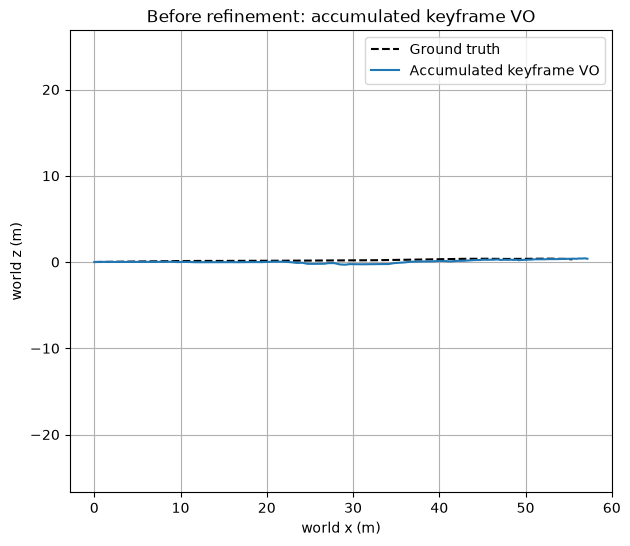

In [37]:
def plot_trajectory(poses, label, style):
    x = [float(pose.t[0]) for pose in poses]
    z = [float(pose.t[2]) for pose in poses]
    plt.plot(x, z, style, label=label)


def translation_rmse(estimated, reference):
    squared_errors = []
    for estimate, truth in zip(estimated, reference):
        difference = np.array(estimate.t, dtype=float) - np.array(truth.t, dtype=float)
        squared_errors.append(difference @ difference)
    return np.sqrt(np.mean(squared_errors))


def final_position_error(estimated, reference):
    difference = (
        np.array(estimated[-1].t, dtype=float)
        - np.array(reference[-1].t, dtype=float)
    )
    return np.linalg.norm(difference)


plt.figure(figsize=(7, 6))
plot_trajectory(true_poses, "Ground truth", "k--")
plot_trajectory(initial_poses, "Accumulated keyframe VO", "C0-")
plt.axis("equal")
plt.xlabel("world x (m)")
plt.ylabel("world z (m)")
plt.title("Before refinement: accumulated keyframe VO")
plt.grid()
plt.legend();

print("Before pose-graph optimisation")
print(f"  Translation RMSE:    {translation_rmse(initial_poses, true_poses):.3f} m")
print(f"  Final-position error: {final_position_error(initial_poses, true_poses):.3f} m")

## 2. Estimate motion over a longer baseline

Consecutive keyframes are not the only pairs with shared visual content. If keyframes $i$ and $i+2$ still overlap, we can match their features and estimate ${}^iT_{i+2}$ **directly**, rather than obtaining it by multiplying ${}^iT_{i+1}$ and ${}^{i+1}T_{i+2}$.

The direct estimate and the accumulated estimate will differ because every motion estimate is noisy. Their disagreement creates redundancy that the pose graph can use to smooth the trajectory. Here each keyframe is also connected to keyframes two, three, and four steps ahead, as long as they remain in the local matching window.

In [9]:
additional_edges = [
    (i, i + gap)
    for gap in (2, 3, 4)
    for i in range(len(true_poses) - gap)
]
additional_measurements = []

for i, j in additional_edges:
    true_relative_pose = true_poses[i].inverse() * true_poses[j]
    noise = rng.normal(
        loc=0.0,
        scale=[0.003, 0.003, 0.004, 0.012, 0.004, 0.012],
    )
    measurement = true_relative_pose.retract(sf.V6(*noise), sf.numeric_epsilon)
    additional_measurements.append(measurement)

print(f"{len(additional_edges)} additional local measurements")

291 additional local measurements


### Visualise a subset of the VO measurements

The plot below shows the first 12 keyframes. A measurement from keyframe $i$ predicts where keyframe $j$ should be when composed with the current pose estimate $X_i$.

The consecutive measurements end exactly at the next accumulated VO pose because those measurements were used to construct the initial trajectory. The independently estimated longer-baseline measurements end nearby, but not at exactly the same location. These disagreements are the errors that the pose graph will reconcile.

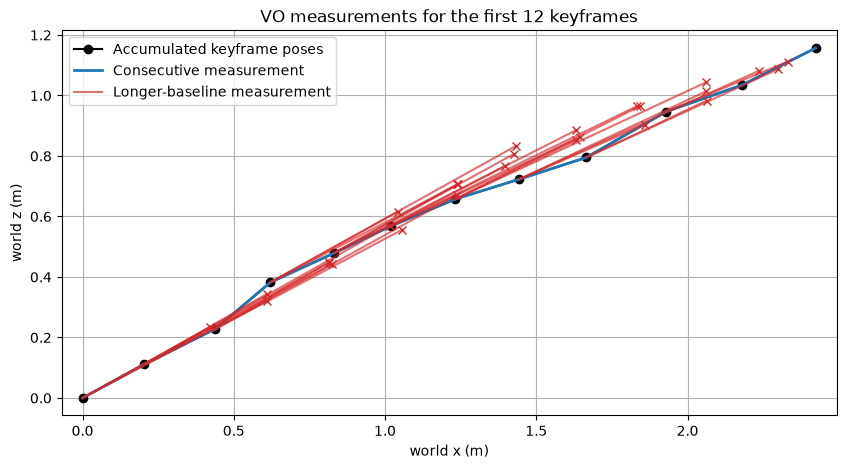

In [10]:
NUM_POSES_TO_SHOW = 12

plt.figure(figsize=(10, 5))
plot_trajectory(
    initial_poses[:NUM_POSES_TO_SHOW],
    "Accumulated keyframe poses",
    "ko-",
)

# Consecutive measurements used to build the initial trajectory.
for i in range(NUM_POSES_TO_SHOW - 1):
    predicted_pose = initial_poses[i] * odometry_measurements[i]
    plt.plot(
        [float(initial_poses[i].t[0]), float(predicted_pose.t[0])],
        [float(initial_poses[i].t[2]), float(predicted_pose.t[2])],
        "C0-",
        linewidth=2,
        label="Consecutive measurement" if i == 0 else None,
    )

# Independent measurements to other keyframes in the local window.
measurement_was_labelled = False
for measurement, (i, j) in zip(additional_measurements, additional_edges):
    if j >= NUM_POSES_TO_SHOW:
        continue
    predicted_pose = initial_poses[i] * measurement
    plt.plot(
        [float(initial_poses[i].t[0]), float(predicted_pose.t[0])],
        [float(initial_poses[i].t[2]), float(predicted_pose.t[2])],
        "C3-",
        alpha=0.65,
        label="Longer-baseline measurement" if not measurement_was_labelled else None,
    )
    plt.plot(float(predicted_pose.t[0]), float(predicted_pose.t[2]), "C3x")
    measurement_was_labelled = True

plt.axis("equal")
plt.xlabel("world x (m)")
plt.ylabel("world z (m)")
plt.title("VO measurements for the first 12 keyframes")
plt.grid()
plt.legend();

## 3. Define the between-pose factor

For each edge, the graph compares the measured relative pose with the relative pose predicted by the two current pose estimates. Ordinary subtraction is not meaningful for rotations, so `local_coordinates` computes their six-dimensional difference on the pose manifold.

Each component is divided by its expected standard deviation. A precise measurement therefore has a larger `sqrt_information` value and contributes more strongly to the objective. SymForce differentiates this function for us; we do not write a Jacobian.

In [13]:
def between_residual(
    pose_a: sf.Pose3,
    pose_b: sf.Pose3,
    measured_a_T_b: sf.Pose3,
    sqrt_information: sf.V6,
    epsilon: sf.Scalar,
) -> sf.V6:
    predicted_a_T_b = pose_a.inverse() * pose_b
    # local_coordinates() expresses the difference from the measured pose to
    # the predicted pose as a 6D tangent-space vector. It is zero when the
    # poses agree and avoids incorrectly subtracting rotation matrices.
    pose_error = measured_a_T_b.local_coordinates(predicted_a_T_b, epsilon)
    return sf.V6(*pose_error).multiply_elementwise(sqrt_information)

## 4. Store the graph values

A `Values` object holds both kinds of quantities in our factor graph:

- **variables:** the world poses that we want to refine;
- **fixed inputs:** the relative-pose measurements, their weights, and epsilon.

The wider-baseline measurements are more precise in this example: more camera translation gives better parallax and a better-conditioned motion estimate. This is not guaranteed—matching also becomes harder as the baseline grows. A real keyframe system would keep only geometrically verified pairs and could set uncertainty from the inlier geometry or motion-fit residuals.

In [14]:
values = Values(
    poses=initial_poses,
    odometry=odometry_measurements,
    additional_motion=additional_measurements,
    odometry_sqrt_information=sf.V6(
        1 / 0.008, 1 / 0.008, 1 / 0.01, 1 / 0.04, 1 / 0.01, 1 / 0.04
    ),
    additional_sqrt_information=sf.V6(
        1 / 0.005, 1 / 0.005, 1 / 0.007, 1 / 0.02, 1 / 0.008, 1 / 0.02
    ),
    epsilon=sf.numeric_epsilon,
)

## 5. Build the factors

A factor connects keys in `Values` to a residual function. We first add one odometry factor for every consecutive keyframe pair. We then add factors for the other measurements in the local keyframe window.

Notice that the graph structure is explicit in the key strings.

In [15]:
factors = []

for i in range(len(odometry_measurements)):
    factors.append(
        Factor(
            residual=between_residual,
            keys=[
                f"poses[{i}]",
                f"poses[{i + 1}]",
                f"odometry[{i}]",
                "odometry_sqrt_information",
                "epsilon",
            ],
        )
    )

for measurement_index, (i, j) in enumerate(additional_edges):
    factors.append(
        Factor(
            residual=between_residual,
            keys=[
                f"poses[{i}]",
                f"poses[{j}]",
                f"additional_motion[{measurement_index}]",
                "additional_sqrt_information",
                "epsilon",
            ],
        )
    )

print(f"{len(initial_poses)} pose variables")
print(f"{len(factors)} relative-pose factors")

100 pose variables
390 relative-pose factors


## 6. Optimise the graph

Relative measurements alone do not define an absolute world frame: moving every pose by the same transform would leave every residual unchanged. We remove this **gauge freedom** by holding `poses[0]` fixed and optimising only poses 1 onward.

In [16]:
keys_to_optimise = [f"poses[{i}]" for i in range(1, len(initial_poses))]

optimizer = Optimizer(
    factors=factors,
    optimized_keys=keys_to_optimise,
    params=Optimizer.Params(verbose=False),
)
result = optimizer.optimize(values)
optimised_poses = result.optimized_values["poses"]

print("Status:", result.status)
print(f"Final squared error: {result.error():.3f}")

Status: optimization_status_t.SUCCESS
Final squared error: 299.005


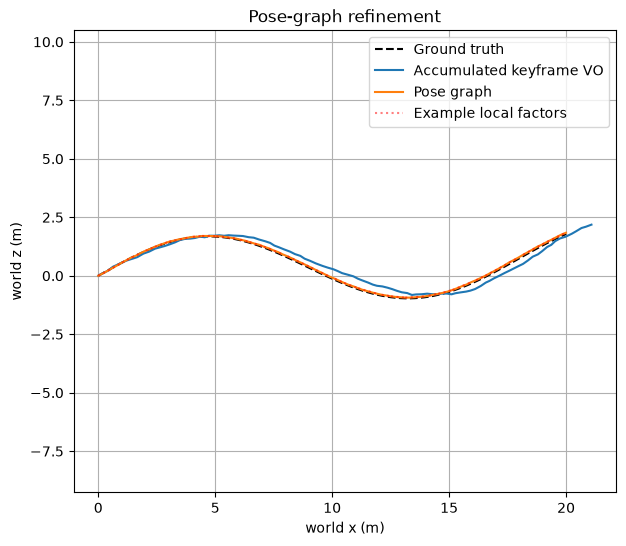

In [17]:
plt.figure(figsize=(7, 6))
plot_trajectory(true_poses, "Ground truth", "k--")
plot_trajectory(initial_poses, "Accumulated keyframe VO", "C0-")
plot_trajectory(optimised_poses, "Pose graph", "C1-")
# Draw a subset of the local factors so the plot remains readable.
for edge_number, (i, j) in enumerate(additional_edges[::10]):
    plt.plot(
        [float(optimised_poses[i].t[0]), float(optimised_poses[j].t[0])],
        [float(optimised_poses[i].t[2]), float(optimised_poses[j].t[2])],
        "r:",
        alpha=0.5,
        label="Example local factors" if edge_number == 0 else None,
    )
plt.axis("equal")
plt.xlabel("world x (m)")
plt.ylabel("world z (m)")
plt.title("Pose-graph refinement")
plt.grid()
plt.legend();

In [18]:
print("After pose-graph optimisation")
print(f"  Translation RMSE:    {translation_rmse(optimised_poses, true_poses):.3f} m")
print(f"  Final-position error: {final_position_error(optimised_poses, true_poses):.3f} m")

After pose-graph optimisation
  Translation RMSE:    0.041 m
  Final-position error: 0.075 m


### Check your understanding

1. Why did the consecutive odometry factors alone not change the accumulated VO trajectory?
2. What would happen if `poses[0]` were also included in `keys_to_optimise`?
3. Increase the standard deviations of `additional_sqrt_information`. How and why does the result change?
4. Extend the local window to keyframe $i+5$. Does it improve the result? What eventually limits how far apart matched keyframes can be?

## 7. Use your own visual-odometry result

The Week 5 notebooks store each relative motion as a SpatialMath `SE3` in the **camera coordinate frame**, where $Z$ points forward. KITTI ground-truth poses use the IMU coordinate frame, where $X$ points forward. Before constructing the graph, change the basis of every relative motion exactly as we did for the Week 5 trajectory plot:

```python
motion_in_imu = T_cam_imu.inv() @ motion_in_camera @ T_cam_imu
```

This changes the coordinate basis without changing the direction of the transform. The Week 5 lists already contain ${}^{k}T_{k+1}$ in the direction needed for trajectory accumulation. The 2D–2D notebook calls its list `relative_motions`; the PnP notebook calls it `relative_motion`.

The Week 5 processing loop always estimates motion between `frame` and `frame + 1`. For this practical, modify that code so it can instead estimate relative motion between any chosen pair `frame_a` and `frame_b`. You will need this for direct measurements between non-consecutive frames. The feature matching, 2D–2D or PnP motion estimation, scale recovery, and transform direction remain the same.

You do not need to introduce keyframes in your own solution. Use every image frame as a pose variable. The existing consecutive-frame motions provide the initial trajectory and the consecutive graph edges.

In [18]:
# Example handover from the Week 5 2D-2D notebook:
from pathlib import Path
import sys
import cv2
support_dir = (Path.cwd().resolve().parents[1] / "support")
if str(support_dir) not in sys.path:
    sys.path.insert(0, str(support_dir))
import kitti_utils as kitti

import symforce
import inspect
# symforce.set_epsilon_to_symbol()

data = kitti.load_kitti_dataset("2011_09_26_drive_0035")
T_cam_imu_matrix = data.camera_calibration(camera=2)['T_cam_imu']
T_cam_imu = SE3.Rt(T_cam_imu_matrix[:3, :3], T_cam_imu_matrix[:3, 3], check=False) # convert it into a spatialmath SE3 object

In [5]:
def ransac_iterations(inlier_ratio, sample_size, confidence=0.99):
    """
    Minimum number of RANSAC iterations needed to have `confidence`
    probability of drawing at least one all-inlier minimal sample.

    inlier_ratio : estimated fraction of correspondences that are inliers (0-1)
    sample_size  : points needed per hypothesis (e.g. 3 for P3P, 5 for five-point, 8 for eight-point)
    confidence   : desired probability of success (default 0.99)
    """
    if inlier_ratio <= 0 or inlier_ratio >= 1:
        raise ValueError("inlier_ratio must be between 0 and 1 (exclusive)")

    numerator = np.log(1 - confidence)
    denominator = np.log(1 - inlier_ratio ** sample_size)
    return int(np.ceil(numerator / denominator))

In [6]:
def estimate_relative_motion(data, frame_a, frame_b):
    left_current = cv2.cvtColor(data.stereo(frame_a)[0], cv2.COLOR_RGB2GRAY)
    right_current = cv2.cvtColor(data.stereo(frame_a)[1], cv2.COLOR_RGB2GRAY)
    left_next = cv2.cvtColor(data.stereo(frame_b)[0], cv2.COLOR_RGB2GRAY)
    # calculate dense disparity for the current frame using the StereoSGBM algorithm
    # first set up the StereoSGBM object with appropriate parameters for the KITTI dataset
    # Typical OpenCV recommendations for the P1 and P2 parameters are: P1 = 8 * channels * blockSize**2; and P2 = 32 * channels * blockSize**2
    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=16 * 10,  # must be divisible by 16
        blockSize=5,
        P1=8 * 1 * 5 ** 2,   # P1: penalty for changing disparity by exactly one pixel. It discourages small fluctuations and surface noise.
        P2=32 * 1 * 5 ** 2,  # P2: penalty for changing disparity by more than one pixel. It strongly discourages sudden depth jumps.
        disp12MaxDiff=1,     # 1 enables the left-right consistency check.
        uniquenessRatio=10,  # like the ratio check: Requires the best disparity candidate to be sufficiently better than competing candidates. A value of 10 means that a match must pass a roughly 10% uniqueness margin.
        speckleWindowSize=100,  # Removes small connected regions of approximately similar disparity.
        speckleRange=32,     # Controls how much disparity variation is permitted while determining whether pixels belong to the same speckle component.
        preFilterCap=63,     
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY        
    )
    
    
    # now calculate the disparity map for the current frame
    disparity = stereo.compute(left_current, right_current).astype(np.float32) / 16.0
    
    # extract ORB features from the left images of the current frame and the next frame
    # orb = ...
    # kp_current, des_current = ...
    # kp_next, des_next = ...
    
    # TODO: Implement this solution.
    orb = cv2.ORB_create(nfeatures=2000)
    kp_current, des_current = orb.detectAndCompute(left_current, None)
    kp_next, des_next = orb.detectAndCompute(left_next, None)
    
    # match the ORB features between the two frames using the Brute-Force-Matcher with Hamming distance
    # bf = ...
    # matches = bf.match(...)
    
    # TODO: Implement this solution.
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    matches = bf.match(des_current, des_next)
    
    # Remember that for P3P / PnP, we need the 3D coordinates of the matched keypoints in the CURRENT frame 
    # and their 2D coordinates in the NEXT frame, after the camera moved. 
    
    # Next we will calculate the 3D coordinates of the matched keypoints in the current camera frame using the disparity map and the camera calibration parameters.
    # To do that, we need the baseline, the focal length (in pixels) and the principal point (cx, cy) from the camera calibration parameters.
    # baseline = ...
    # focal_length = ...
    # cx, cy = ...
          
    # TODO: Implement this solution.
    # baseline = baseline
    # fx, fy = fx, fy
    # cx, cy = cx, cy
    
    # We will store the 3D coordinates of the matched keypoints in the current frame, 
    # and their pixel coordinates in the next frame, in two separate lists.
    points_3d_current = []
    points_2d_next = [] 

    # Now we are ready to loop over the matches and calculate the 3D coordinates of the matched keypoints in the current frame using the disparity map and the camera calibration parameters.
    for match in matches:
        # get the coordinates of the matched keypoints in the left image of the current frame
        # pt_current = ...
        # pt_next = ...
        # TODO: Implement this solution.
        
        pt_current = kp_current[match.queryIdx].pt
        pt_next = kp_next[match.trainIdx].pt
                
        # get the disparity value for the matched keypoint in the current frame
        # disparity_value = ...
        # TODO: Implement this solution.
        u, v = int(round(pt_current[0])), int(round(pt_current[1]))
        disparity_value = disparity[v, u]
        
        # if the disparity value is valid (i.e., greater than 0), calculate the 3D coordinates using the triangulation formulas we saw in Week 3
        # Hint: Filtering only disparity > 0 admits very small disparities and therefore extremely uncertain, distant points. A minimum disparity or maximum-depth threshold might improve robustness.
        if disparity_value > 0:
            # first calculate the depth (Z coordinate) using the baseline and focal length from the camera calibration parameters        
            # Z = ...
            # then calculate the X and Y coordinates using the pixel coordinates, the principal point, and the depth Z
            # X = ...   
            # Y = ...
            # TODO: Implement this solution.
            Z = (fx * baseline) / disparity_value
            X = (pt_current[0] - cx) * Z / fx
            Y = (pt_current[1] - cy) * Z / fy
            
            # append the triangulated 3D point to the list
            points_3d_current.append([X, Y, Z])
            # also append the pixel coordinates of the matched keypoint in the next frame to its list
            points_2d_next.append([pt_next[0], pt_next[1]])

    # Now we are ready to run P3P followed by an iterative PnP refinement to estimate the camera pose (rotation and translation) of the next frame relative to the current frame.
    # Remember that we should always do P3P inside a RANSAC loop to reject outliers, and then refine the pose using an iterative PnP method (e.g., Levenberg-Marquardt) on the inliers.
    
    # P3P needs 4 matched points (3 for the relative pose information and 1 to resolve the ambiguity), so we only proceed if we have at least 4 matched points.     
    if len(points_2d_next) >= 4:
        
        # convert the 3d and 2d points to numpy arrays
        points_3d = np.array(points_3d_current)
        points_2d = np.array(points_2d_next)
        
        # for the next steps we also need K, the intrinsic camera calibration matrix, which we can get from the KITTI dataset using the `camera_calibration` function.
        K = data.camera_calibration(2)["K"]
        
        # use P3P in a RANSAC loop to estimate the camera pose (rotation and translation) of the next frame relative to the current frame
        # In the lecture I recommended using the `cv2.solvePnPRansac` function. Experiment with the different settings, e.g. AP3P vs P3P, different reprojection error thresholds, different number of RANSAC iterations, etc. to see how they affect the results.
        # Attention! Depending on the OpenCV version you are using, you might have to explicitly give the function a `distCoeffs=None` argument to avoid an error message.
        
        # ok, rvec, tvec, inliers = ...
        
        # TODO: Implement this solution.
        N = ransac_iterations(inlier_ratio=0.5, sample_size=3, confidence=0.99)
        ok, rvec, tvec, inliers = cv2.solvePnPRansac(points_3d, points_2d, K, flags=cv2.SOLVEPNP_AP3P, reprojectionError=1.25, distCoeffs=None, iterationsCount=N)
        
        # reshape the inliers to a 1D array of indices
        idx = inliers.flatten()
        
        # Now use the iterative least squares PnP method (e.g., Levenberg-Marquardt) to refine the camera pose estimate using only the inliers from the RANSAC step.        
        # Experiment with different settings and methods, e.g. you can use solvePnPRefineLM or solvePnPRefineVVS. 
        # You can also try different initial guesses for the rotation and translation vectors, e.g. you can use the output of the RANSAC step as the initial guess, or you can use the identity matrix and zero vector as the initial guess and see how that affects the results.
        # Check the lecture slides for a simple recipe of calling the `cv2.solvePnPRefineLM` function. You can also check the OpenCV documentation for more details on the different options and parameters.
        
        # rvec, tvec = ...

        # TODO: Implement this solution.
        rvec, tvec = cv2.solvePnPRefineVVS(points_3d[idx], points_2d[idx], K, None, rvec, tvec)
        
        # convert the rotation vector to a rotation matrix using the `cv2.Rodrigues` function, and then construct the SE3 transformation matrix from the rotation matrix and translation vector. 
        R = cv2.Rodrigues(rvec)[0]        
        T = SE3.Rt(R, tvec)
        T = T.inv()  # invert the transformation to get the relative motion from the current frame to the next frame
        
        # append the relative motion to the list
        return T

In [39]:
relative_motion = []

left_calibration = data.camera_calibration(camera=2)
right_calibration = data.camera_calibration(camera=3)
K = left_calibration['K']

T_right_left = right_calibration['T_cam_imu'] @ np.linalg.inv(left_calibration['T_cam_imu'])
baseline = np.linalg.norm(T_right_left[:3, 3])
fx, fy = K[0, 0], K[1, 1]
cx, cy = K[0, 2], K[1, 2]

# consecutive: same as before, drives the initial trajectory
relative_motion = [
    estimate_relative_motion(data, i, i + 1)
    for i in range(data.frame_count - 1)
]

# non-consecutive: the extra graph edges
additional_edges = [(i, i + 3) for i in range(data.frame_count - 3)]
additional_measurements_raw = [
    estimate_relative_motion(data, a, b) for a, b in additional_edges
]

# additional_measurements = [
#     spatialmath_to_symforce(T_cam_imu.inv() @ motion @ T_cam_imu)
#     for motion in additional_measurements_raw
# ]
        
  

In [40]:
frame_motions_in_imu = [
    T_cam_imu.inv() @ motion @ T_cam_imu
    for motion in relative_motion
]

errors = []
for i, motion in enumerate(frame_motions_in_imu):
    M_gt = data.ground_truth_pose(i).inv() * data.ground_truth_pose(i + 1)
    errors.append((M_gt.inv() * motion).log(twist=True))

errors = np.array(errors)
sigma = np.maximum(errors.std(axis=0), 1e-4)

odometry_measurements = [
    spatialmath_to_symforce(motion)
    for motion in frame_motions_in_imu
]

initial_poses = [sf.Pose3.identity()]
for relative_pose in odometry_measurements:
    initial_poses.append(initial_poses[-1] * relative_pose)

# For comparison with KITTI ground truth:
true_poses = [
    spatialmath_to_symforce(data.ground_truth_pose(frame))
    for frame in range(data.frame_count)
]

In [41]:
def between_residual(
    pose_a: sf.Pose3,
    pose_b: sf.Pose3,
    measured_a_T_b: sf.Pose3,
    sqrt_information: sf.V6,
    epsilon: sf.Scalar,
) -> sf.V6:
    predicted_a_T_b = pose_a.inverse() * pose_b
    # local_coordinates() expresses the difference from the measured pose to
    # the predicted pose as a 6D tangent-space vector. It is zero when the
    # poses agree and avoids incorrectly subtracting rotation matrices.
    pose_error = measured_a_T_b.local_coordinates(predicted_a_T_b, epsilon)
    return sf.V6(*pose_error).multiply_elementwise(sqrt_information)

In [49]:
# errors = []
# for i in range(len(relative_motion)):
#     M_meas = relative_motion[i]                       # T_{i<-i+1}, IMU frame
#     M_gt   = data.ground_truth_pose(i).inv() * data.ground_truth_pose(i + 1)
#     err = (M_gt.inv() * M_meas).log(twist=True)              # 6-vector
#     errors.append(err)

# errors = np.array(errors)
# sigma = np.maximum(errors.std(axis=0), 1e-4)                           # per-component

additional_in_imu = [
    T_cam_imu.inv() @ motion @ T_cam_imu
    for motion in additional_measurements_raw
]

errors_additional = []
for motion, (a, b) in zip(additional_in_imu, additional_edges):
    M_gt = data.ground_truth_pose(a).inv() * data.ground_truth_pose(b)
    errors_additional.append((M_gt.inv() * motion).log(twist=True))


errors_additional = np.array(errors_additional)
sigma_additional  = np.maximum(errors_additional.std(axis=0), 1e-4)                             # per-component

sigma_sf            = np.concatenate([sigma[3:], sigma[:3]])
sigma_additional_sf = np.concatenate([sigma_additional[3:], sigma_additional[:3]])

additional_measurements = [spatialmath_to_symforce(m) for m in additional_in_imu]

print(len(additional_measurements), len(additional_edges))
for k in [0, 1, 50, 127]:
    a, b = additional_edges[k]
    M_gt = data.ground_truth_pose(a).inv() * data.ground_truth_pose(b)
    print(k, (a, b), np.linalg.norm(np.array(M_gt.t) - np.array(additional_measurements[k].t, dtype=float).ravel()))

values = Values(
    poses=initial_poses,
    odometry=odometry_measurements,
    additional_motion=additional_measurements,
    # odometry_sqrt_information = sf.V6(*[float(x) for x in (1.0 / sigma_sf)]),
    # additional_sqrt_information=sf.V6(*(1.0 / sigma_additional_sf)),
    odometry_sqrt_information=sf.V6(1/0.008, 1/0.008, 1/0.01, 1/0.04, 1/0.01, 1/0.04),
    additional_sqrt_information=sf.V6(1/0.005, 1/0.005, 1/0.007, 1/0.02, 1/0.008, 1/0.02),
    epsilon=sf.numeric_epsilon,
)

print("sigmas: ", sigma)
print("sigmas_additional : ", sigma_additional)

for k in [0, 1, 50, 127]:
    a, b = additional_edges[k]
    M_gt = data.ground_truth_pose(a).inv() * data.ground_truth_pose(b)
    meas = additional_in_imu[k]
    print(k, np.linalg.norm(M_gt.t), np.linalg.norm(meas.t))

128 128
0 (0, 3) 0.14652554212848826
1 (1, 4) 0.33473720891247144
50 (50, 53) 0.203167935771839
127 (127, 130) 0.1104675547842328
sigmas:  [0.05317904 0.04215882 0.02790995 0.00133627 0.00081596 0.00128104]
sigmas_additional :  [0.98986529 0.72027426 0.13764001 0.01344363 0.00260642 0.01223468]
0 2.0234513737753934 2.144367404031858
1 2.0261462293727046 2.30987514989675
50 1.7727812525424351 1.9532126755477204
127 1.4294812068417166 1.5083729674300212


In [43]:
factors = []
initial_poses = list(initial_poses)

for i in range(len(odometry_measurements)):
    factors.append(
        Factor(
            residual=between_residual,
            keys=[
                f"poses[{i}]",
                f"poses[{i + 1}]",
                f"odometry[{i}]",
                "odometry_sqrt_information",
                "epsilon",
            ],
        )
    )

for measurement_index, (i, j) in enumerate(additional_edges):
    factors.append(
        Factor(
            residual=between_residual,
            keys=[
                f"poses[{i}]",
                f"poses[{j}]",
                f"additional_motion[{measurement_index}]",
                "additional_sqrt_information",
                "epsilon",
            ],
        )
    )

print(f"{len(initial_poses)} pose variables")
print(f"{len(factors)} relative-pose factors")

print(inspect.getsource(spatialmath_to_symforce))
print({type(p) for p in values["poses"]})
print({type(m) for m in values["odometry"]})
print({type(m) for m in values["additional_motion"]})

131 pose variables
258 relative-pose factors
def spatialmath_to_symforce(spatial_pose):
    """Convert a SpatialMath SE3 into a SymForce Pose3."""
    T = spatial_pose.A
    rotation = sf.Rot3.from_rotation_matrix(sf.Matrix33(T[:3, :3]))
    translation = sf.V3(*T[:3, 3])
    return sf.Pose3(rotation, translation)

{<class 'symforce.geo.pose3.Pose3'>}
{<class 'symforce.geo.pose3.Pose3'>}
{<class 'symforce.geo.pose3.Pose3'>}


In [44]:
between_residual(
    values["poses"][0],
    values["poses"][1],
    values["odometry"][0],
    values["odometry_sqrt_information"],
    values["epsilon"],
)

[0]
[0]
[0]
[0]
[0]
[0]

In [45]:

keys_to_optimise = [f"poses[{i}]" for i in range(1, len(initial_poses))]

optimizer = Optimizer(
    factors=factors,
    optimized_keys=keys_to_optimise,
    params=Optimizer.Params(verbose=False),
)
result = optimizer.optimize(values)
optimised_poses = result.optimized_values["poses"]



print("Status:", result.status)
print(f"Final squared error: {result.error():.3f}")

Status: optimization_status_t.SUCCESS
Final squared error: 142519.372


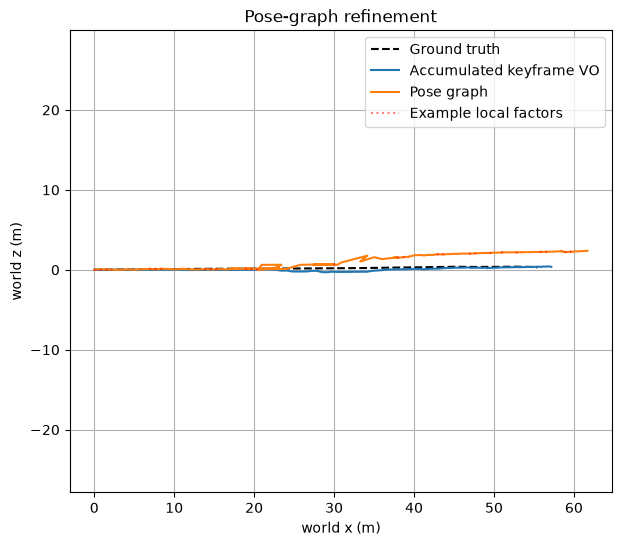

In [38]:
plt.figure(figsize=(7, 6))
plot_trajectory(true_poses, "Ground truth", "k--")
plot_trajectory(initial_poses, "Accumulated keyframe VO", "C0-")
plot_trajectory(optimised_poses, "Pose graph", "C1-")
# Draw a subset of the local factors so the plot remains readable.
for edge_number, (i, j) in enumerate(additional_edges[::10]):
    plt.plot(
        [float(optimised_poses[i].t[0]), float(optimised_poses[j].t[0])],
        [float(optimised_poses[i].t[2]), float(optimised_poses[j].t[2])],
        "r:",
        alpha=0.5,
        label="Example local factors" if edge_number == 0 else None,
    )
plt.axis("equal")
plt.xlabel("world x (m)")
plt.ylabel("world z (m)")
plt.title("Pose-graph refinement")
plt.grid()
plt.legend();

### Additional non-consecutive frame factors

The existing Week 5 motions provide the consecutive frame edges and the initial trajectory.

For an additional graph edge such as $(i, i+2)$, use your modified Week 5 code to estimate motion **directly** between image frames `i` and `i + 2`. Change that measurement from the camera basis into the IMU basis, convert it to `Pose3`, and store the graph edge using the frame indices `(i, i + 2)`. Repeat for other overlapping frame pairs such as $(i, i+3)$ while the images still share enough visual content.


## Take-away

A pose graph does not create new information: it makes all available relative-pose measurements agree as well as possible. Consecutive keyframe edges provide the initial trajectory. Direct estimates to other overlapping keyframes in a local window add redundancy and allow the optimiser to smooth inconsistent motion estimates. Measurement direction, uncertainty, a good initial guess, and a fixed reference pose are all essential.